In [1]:
# This notebook demonstrates how to use ROSALIA to analyze stray light in a simple exposure. 
import rosalia as rs
import numpy as np
import rosalia as rs
import matplotlib.pyplot as plt# os.system("cp -v /Users/aborlaff/NASA/ROSALIA_DEPOT/MAST_2026-09-16T0933_BAK/MAST/Roman/r0102001002001005001_0004_wfi*.asdf /Users/aborlaff/NASA/ROSALIA_DEPOT/MAST_2026-09-16T0933/MAST/Roman/" )
from matplotlib.colors import SymLogNorm

path = "/Users/aborlaff/NASA/ROSALIA_DEPOT/MAST_2026-09-16T0933/MAST/Roman/r0102001002001005001_0004_wfi*_f158_cal.asdf"
custom_roman_exposure = rs.core.exposure(filename=path) 
# straylight_out = custom_roman_exposure.straylight(verbose=True)


100%|██████████| 18/18 [00:04<00:00,  3.67it/s]


Computing Zodiacal light...


100%|██████████| 18/18 [01:31<00:00,  5.08s/it]


3.5625466354552238
3.682564493848777


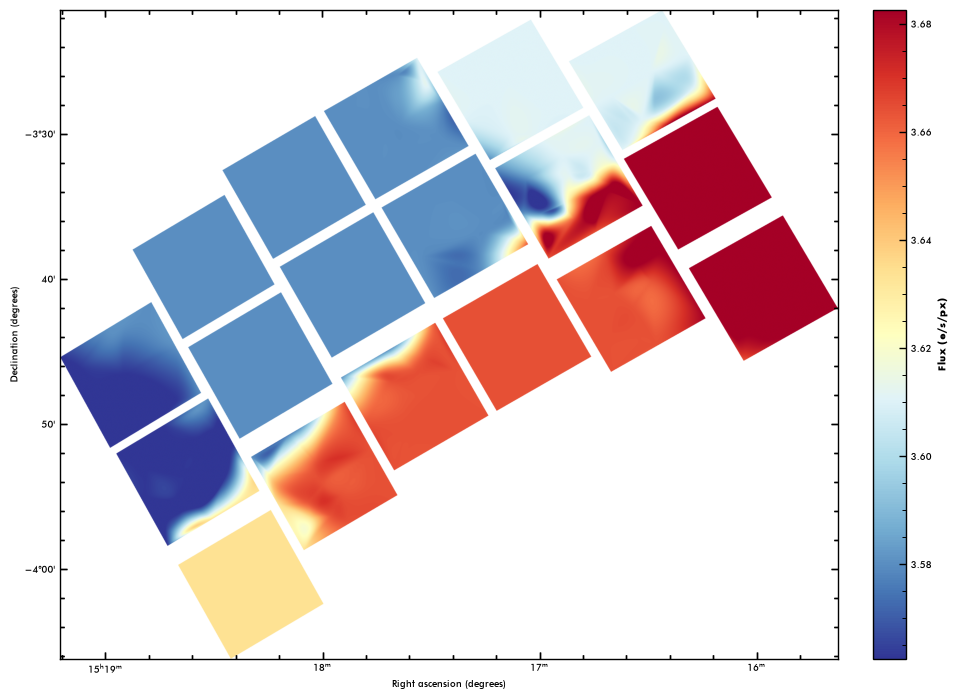

DEMO WARNING: make_stray_plot is Assuming F129.
20.268239695179734
20.304214203508952


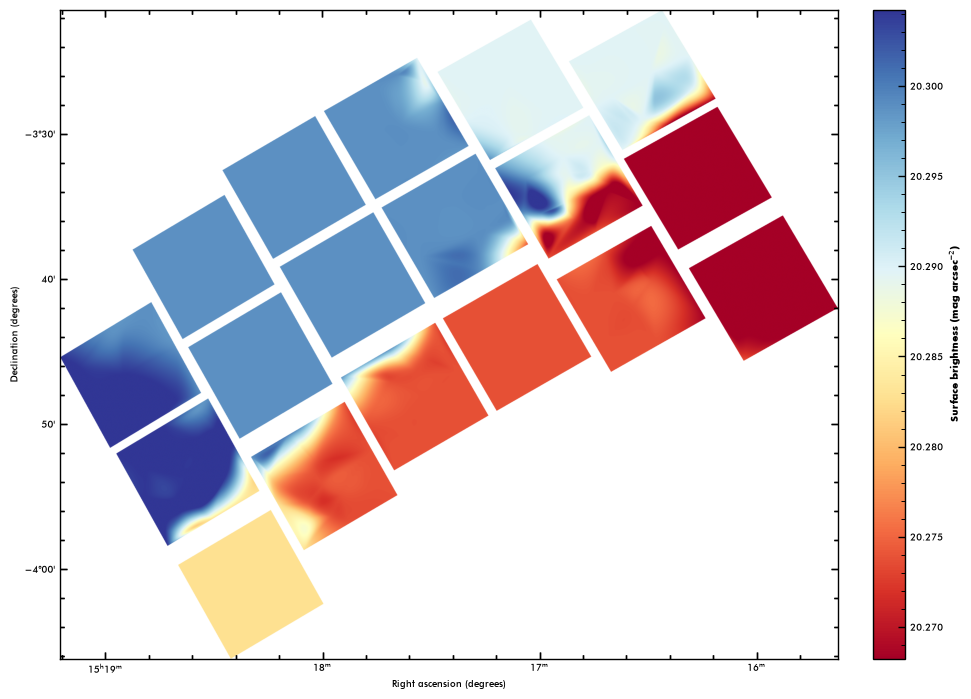

Output saved in: /Users/aborlaff/NASA/ROSALIA_DEPOT/MAST_2026-09-16T0933/MAST/Roman/r0102001002001005001_0004_wfi09_f158_cal_zody.fits


{'zodi_list': [array([[3.61074598, 3.61074591, 3.61074584, ..., 3.61074439, 3.61074519,
          3.61074598],
         [3.61074603, 3.61074595, 3.61074588, ..., 3.61074571, 3.61074651,
          3.61074731],
         [3.61074607, 3.610746  , 3.61074593, ..., 3.61074703, 3.61074784,
          3.61074864],
         ...,
         [3.68239679, 3.68238615, 3.68237555, ..., 3.61073542, 3.61072782,
          3.61072016],
         [3.68248061, 3.6824701 , 3.68245967, ..., 3.61074846, 3.61074078,
          3.61073306],
         [3.68256449, 3.68255411, 3.68254377, ..., 3.61076173, 3.61075382,
          3.61074598]], shape=(4088, 4088)),
  array([[3.5802245 , 3.58023141, 3.58023829, ..., 3.56241405, 3.56241668,
          3.56241931],
         [3.58020865, 3.58021562, 3.5802226 , ..., 3.56241694, 3.56241955,
          3.56242218],
         [3.58019278, 3.58019976, 3.5802068 , ..., 3.56241979, 3.56242241,
          3.56242504],
         ...,
         [3.63350155, 3.6335008 , 3.63349967, ..., 3.56

In [2]:
custom_roman_exposure.zodiacal(zody_mode="stsci")

In [ ]:
# Quick aperture photometry 
# dragon_flux_sum = 520495.06 # DN/s	2.23559
# background_sum = 347943.57	# DN/s 	1.59042

In [ ]:
custom_roman_exposure.SCIEXTS

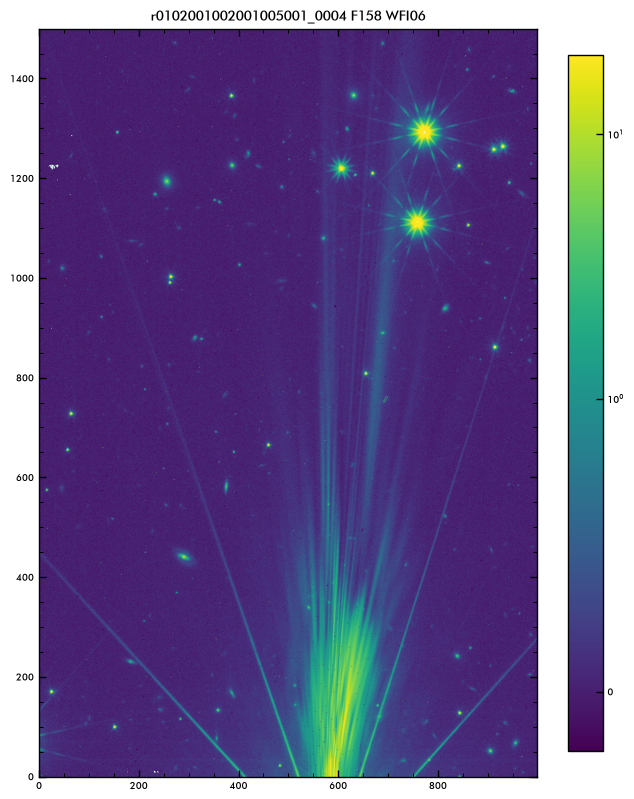

In [11]:
# Index 3 holds the affected exposure. 
image = custom_roman_exposure.DATA[3]
sky = np.nanmedian(custom_roman_exposure.DATA[3])
skycor = image[0:1500, 500:1500] - sky

fig, ax = plt.subplots(figsize=(8,8))
im = ax.imshow(skycor, origin="lower",
               norm=SymLogNorm(linthresh=1, vmin=-0.2, vmax=20))
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)      
ax.set_title("r0102001002001005001_0004 F158 WFI06", fontsize=10)
plt.tight_layout()
plt.savefig("r0102001002001005001_0004_F158_WFI06.png", dpi=300)


In [ ]:
# Make a radial profile
# First save the image to a fits file
drz_data, drz_wcs, outname = custom_roman_exposure.save_drz(outname="dragon_snap.fits",  
                               data_list=[custom_roman_exposure.DATA[3]-sky], 
                               wcs_list=[custom_roman_exposure.ASTROPYWCS[3]], resolution=0.11)



In [51]:
ra_dragon_center = 229.6405032
dec_dragon_center = -3.5874811
# radial_mask = rs.utils.create_radial_mask(xsize=image.shape[0], ysize=image.shape[1], q=0.5, theta=-45, center=[2549.2, 4867.4], radius=None)
rbins = np.linspace(0, 2000, 250)

xcen = 2551
ycen = 4856
pa=22
q = 0.25
profile = rs.utils.make_profile(image="dragon_snap.fits", ext=0, xcen=2551, ycen=4856, rbins=rbins,
                                q=q, theta=pa)

rs.utils.save_fits(profile["model"], "radial_mask.fits")



Input image:dragon_snap.fits
No valid WCS found. Pixscale set to 1
Using xcen and ycen supplied by user
X2551 - Y: 4856


100%|██████████| 249/249 [00:25<00:00,  9.85it/s]


'radial_mask.fits'

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))


ysnap = 4000
xsnap = 2200
width = 1000
ax.imshow(drz_data[ysnap:ysnap+width,xsnap:xsnap+width], origin="lower", norm=SymLogNorm(linthresh=1, vmin=-0.2, vmax=20))
from matplotlib.patches import Ellipse
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=r'Flux (DN/s)')      
ax.set_title("r0102001002001005001_0004 F158 WFI06", fontsize=14)

radius = np.linspace(0,1500,25)
for r in radius:
    ellipse = Ellipse(xy=(xcen-xsnap, ycen-ysnap), width=q*r, height=r, angle=pa,
                    edgecolor='red', linestyle='--', facecolor='none', linewidth=1)
    ax.add_patch(ellipse)

ax.set_xlabel("X (pixel)")
ax.set_ylabel("Y (pixel)")
plt.savefig("r0102001002001005001_0004_Dragon_ellipses.png", dpi=300)
plt.show()


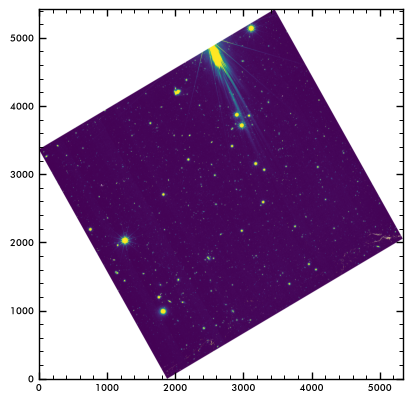

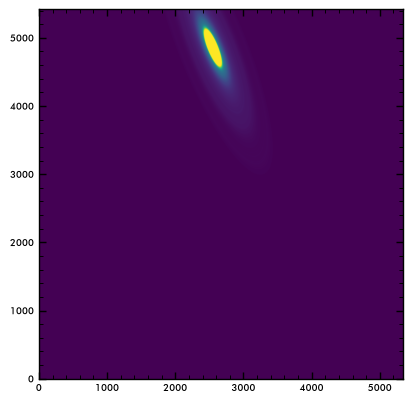

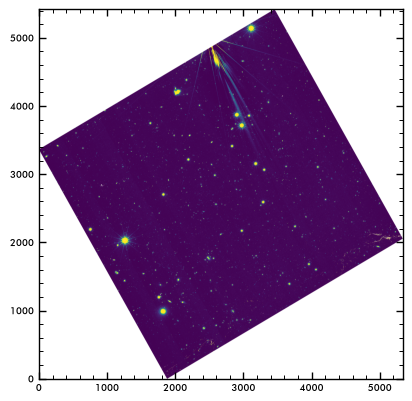

In [54]:
# profile["model"].shape
plt.imshow(drz_data, origin="lower", vmin=0, vmax=1)
plt.show()
plt.imshow(profile["model"], origin="lower", vmin=0, vmax=1)
plt.show()
plt.imshow(drz_data - profile["model"], origin="lower", vmin=0, vmax=1)
plt.show()

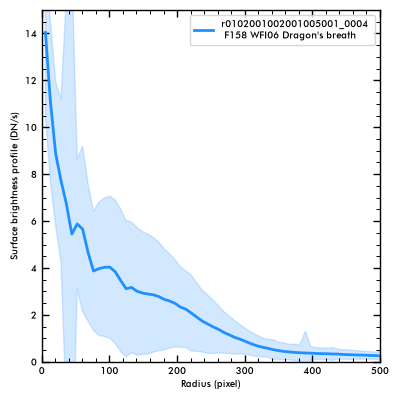

In [57]:
fig, ax = plt.subplots(figsize=(4,4))
ax.plot(profile["profile"]["r"], profile["profile"]["int"], linewidth=2, color="dodgerblue",
        label="r0102001002001005001_0004 \n F158 WFI06 Dragon's breath")
ax.fill_between(x=profile["profile"]["r"], 
                y1=profile["profile"]["int_s1down"],
                y2=profile["profile"]["int_s1up"], alpha=0.2, color="dodgerblue")

ax.set_ylim(0, 15)
ax.set_xlim(0,500)
ax.set_ylabel("Surface brightness profile (DN/s)")
ax.set_xlabel("Radius (pixel)")
ax.legend()
plt.tight_layout()
plt.savefig("r0102001002001005001_0004_Dragon_profile.png", dpi=300)

In [ ]:
profile["profile"]["r"]